In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the parquet file
df = pd.read_parquet("merged_data.parquet")
print(df['timestamp'].min())


2024-01-01 00:00:00


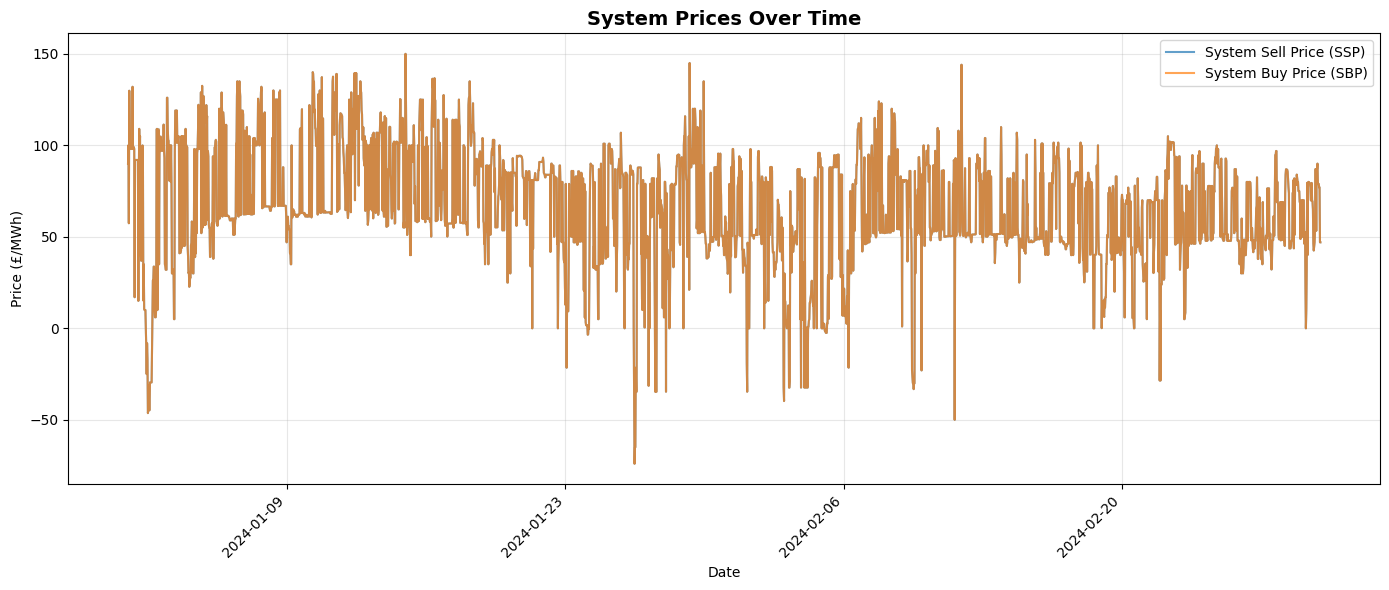

In [15]:
# Plot 1: System Prices Over Time
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['timestamp'], df['ssp'], label='System Sell Price (SSP)', alpha=0.7, linewidth=1.5)
ax.plot(df['timestamp'], df['sbp'], label='System Buy Price (SBP)', alpha=0.7, linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Price (£/MWh)')
ax.set_title('System Prices Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


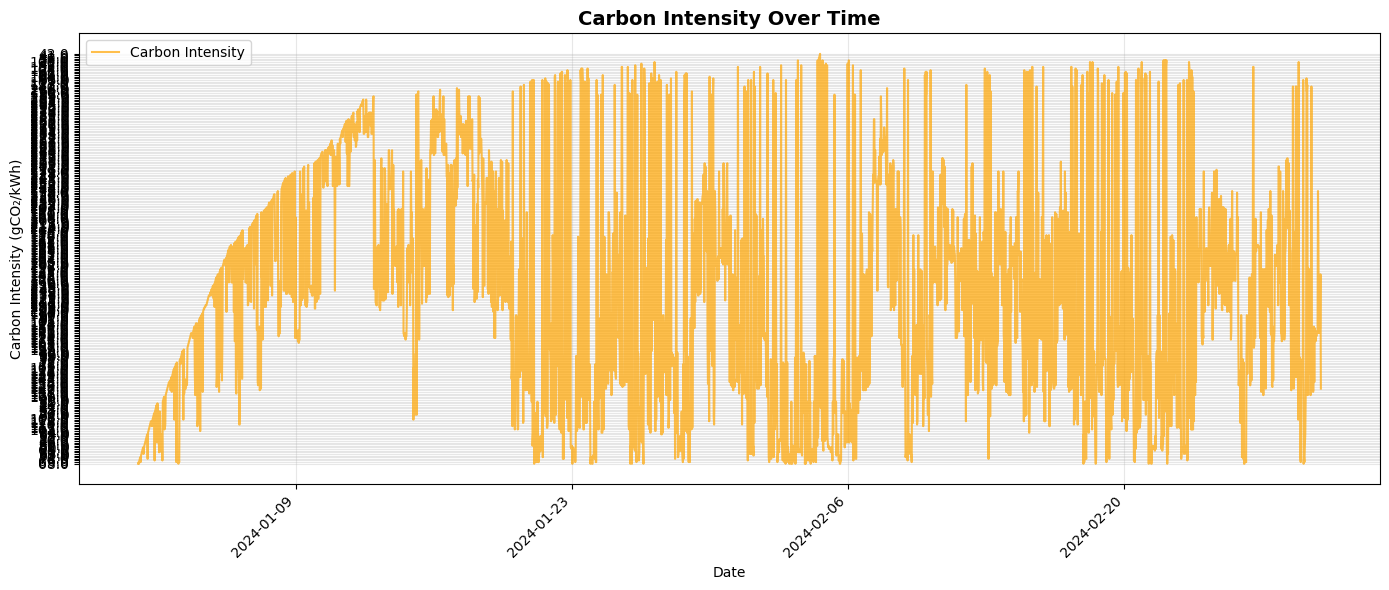

In [16]:
# Plot 2: Carbon Intensity Over Time
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['timestamp'], df['carbon_gco2_kwh'], label='Carbon Intensity', 
        color='orange', alpha=0.7, linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Carbon Intensity (gCO₂/kWh)')
ax.set_title('Carbon Intensity Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


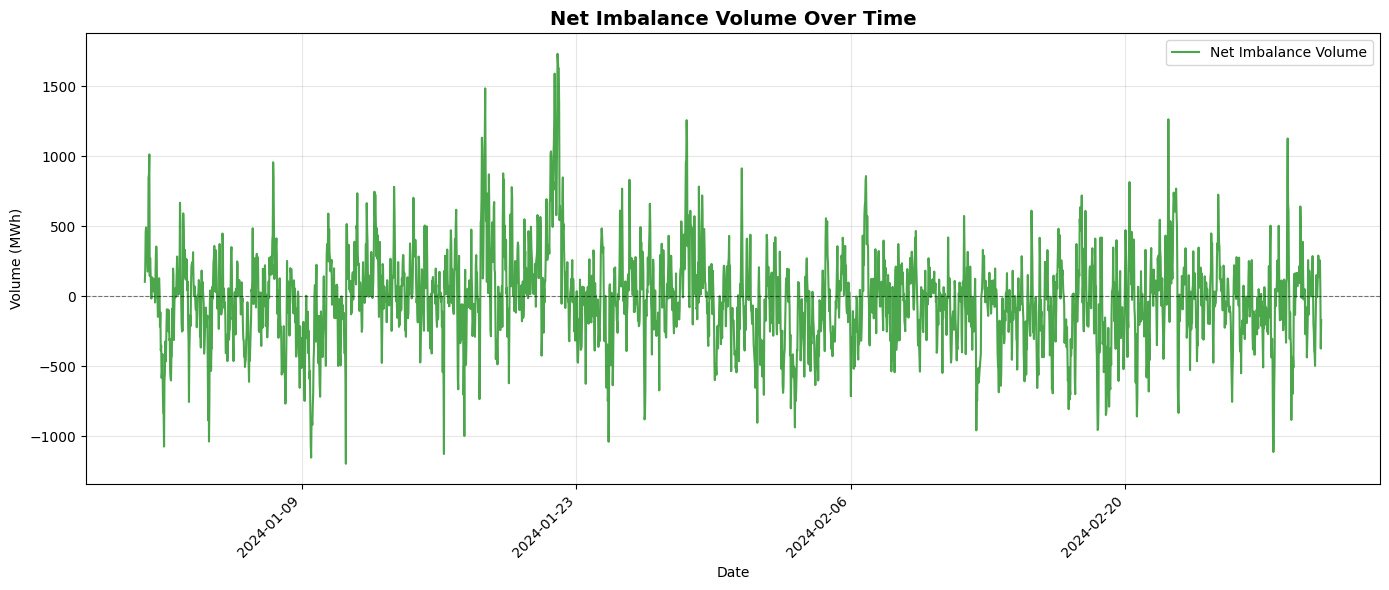

In [17]:
# Plot 3: Net Imbalance Volume
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['timestamp'], df['niv'], label='Net Imbalance Volume', 
        color='green', alpha=0.7, linewidth=1.5)
ax.set_xlabel('Date')
ax.set_ylabel('Volume (MWh)')
ax.set_title('Net Imbalance Volume Over Time', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


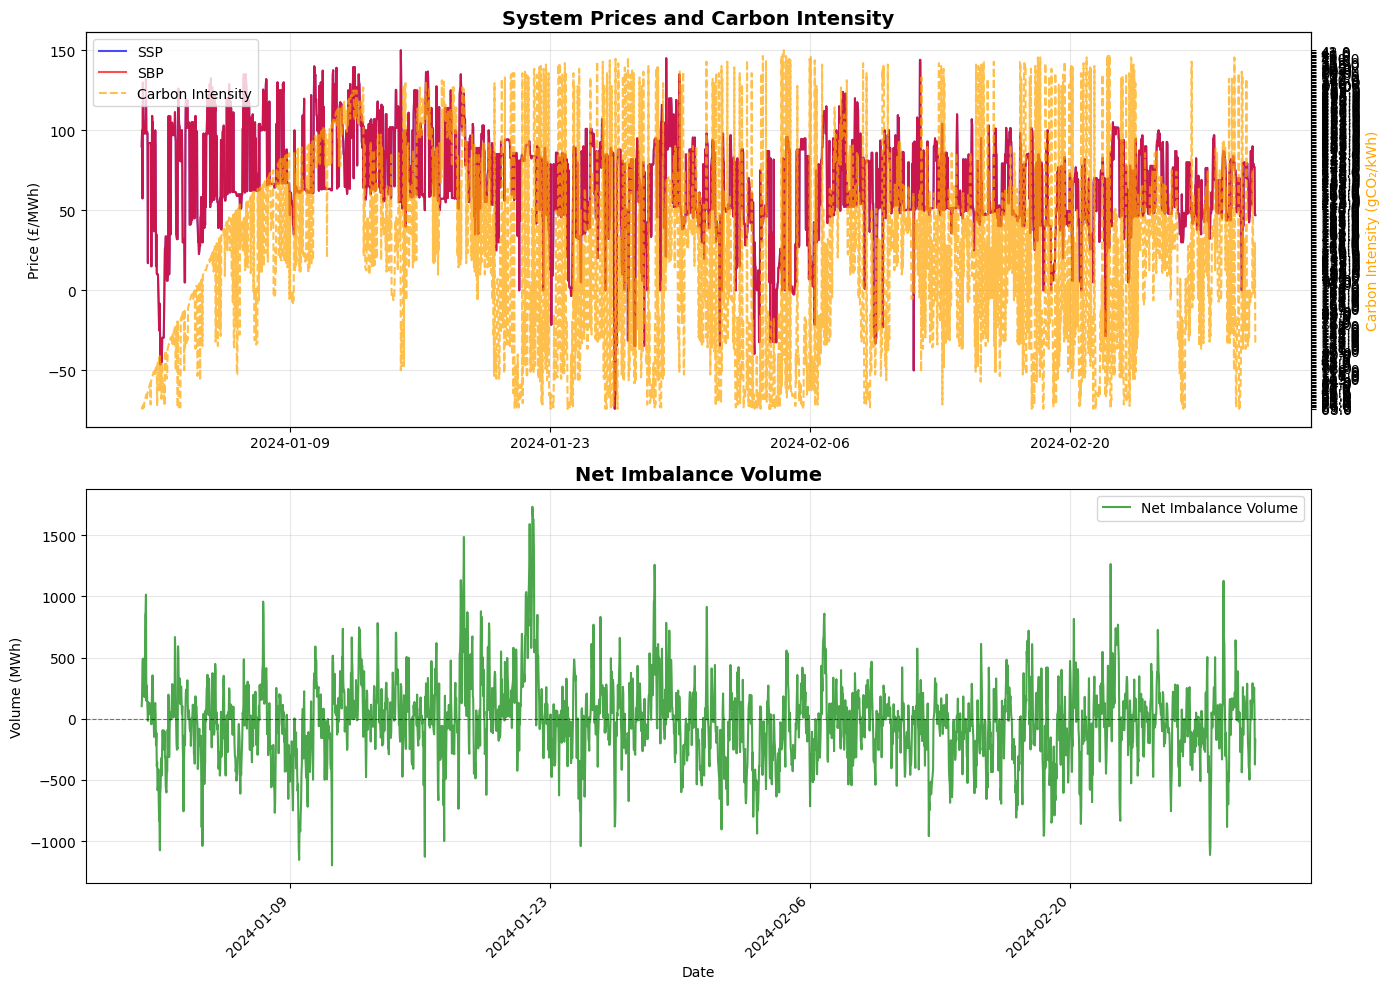

In [18]:
# Plot 4: Combined Overview
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Prices and Carbon Intensity
ax1 = axes[0]
ax1_twin = ax1.twinx()
line1 = ax1.plot(df['timestamp'], df['ssp'], label='SSP', color='blue', alpha=0.7, linewidth=1.5)
line2 = ax1.plot(df['timestamp'], df['sbp'], label='SBP', color='red', alpha=0.7, linewidth=1.5)
line3 = ax1_twin.plot(df['timestamp'], df['carbon_gco2_kwh'], label='Carbon Intensity', 
                      color='orange', alpha=0.7, linewidth=1.5, linestyle='--')
ax1.set_ylabel('Price (£/MWh)', color='black')
ax1_twin.set_ylabel('Carbon Intensity (gCO₂/kWh)', color='orange')
ax1.set_title('System Prices and Carbon Intensity', fontsize=14, fontweight='bold')
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))

# Net Imbalance Volume
ax2 = axes[1]
ax2.plot(df['timestamp'], df['niv'], label='Net Imbalance Volume', 
         color='green', alpha=0.7, linewidth=1.5)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volume (MWh)')
ax2.set_title('Net Imbalance Volume', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [19]:
import pandas as pd
